## Task 1

In [14]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os


Create GrayScale Images

In [15]:
path = 'Images/'
img_matrix = []
for i,file in enumerate(os.listdir(path)):
    img = Image.open(f'Images/{file}').convert('L')
    img = img.resize((2000,1000))
    img.save(f'GreyScale/image{i}.png')
    M = np.array(img, dtype = float).flatten()
    img_matrix.append(M)

Flatten

In [16]:
X = np.vstack(img_matrix)

Moi hang dai dien cho mot buc anh, ma tran co 8 hang tuong duong voi 8 anh greyscale

Moi cot the hien gia tri cua do sang pixel, nam trong khoang tu 0 den 255. X\[i,j] tra ve do sang cua pixel thu j cua buc anh thu i


### Phép toán cơ bản. Tính vector trung bình theo cột, trừ trung bình (broadcasting); in shape trước/sau để minh họa quy tắc broadcasting

In [17]:
mean = np.mean(X,0,float,keepdims=True)
print('Matrix X:')
print(X)
print('Matrix Mean:')
print(mean)
print('Matrix K -mean:')
K = X - mean
print(K)

Matrix X:
[[183. 188. 187. ... 141. 169. 134.]
 [206. 206. 206. ...  30.  30.  29.]
 [ 86.  86.  86. ...  54.  68.  71.]
 ...
 [192. 192. 192. ... 212. 217. 222.]
 [196. 196. 191. ...  52.  43.  41.]
 [175. 175. 175. ...  85.  75.  72.]]
Matrix Mean:
[[162.    162.625 161.875 ...  77.75   81.25   77.125]]
Matrix K -mean:
[[ 21.     25.375  25.125 ...  63.25   87.75   56.875]
 [ 44.     43.375  44.125 ... -47.75  -51.25  -48.125]
 [-76.    -76.625 -75.875 ... -23.75  -13.25   -6.125]
 ...
 [ 30.     29.375  30.125 ... 134.25  135.75  144.875]
 [ 34.     33.375  29.125 ... -25.75  -38.25  -36.125]
 [ 13.     12.375  13.125 ...   7.25   -6.25   -5.125]]


### Cosine similarity. Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn hóa theo hàng, keepdims=True), trả về ma trận tương đồng.

In [18]:

def cosine_similarity(X, Y = None):
    if Y is None:
        Y = X
    Xn = X/ np.linalg.norm(X, axis = 1, keepdims=True)
    Yn = Y/ np.linalg.norm(Y, axis = 1, keepdims=True)
    return Xn @ Yn.T

print('Cosine Similar Matrix:')
Cosine_matrix = cosine_similarity(X)
print(f'Cosine Similar Shape{Cosine_matrix.shape}')
print(Cosine_matrix)


Cosine Similar Matrix:


Cosine Similar Shape(8, 8)
[[1.         0.92000198 0.90078815 0.76815764 0.88516518 0.88167224
  0.89841747 0.90507726]
 [0.92000198 1.         0.94031334 0.77072868 0.91779533 0.88220404
  0.91368779 0.93711844]
 [0.90078815 0.94031334 1.         0.81384979 0.93493498 0.87081578
  0.92247531 0.91113461]
 [0.76815764 0.77072868 0.81384979 1.         0.85118016 0.82519091
  0.84025687 0.80230357]
 [0.88516518 0.91779533 0.93493498 0.85118016 1.         0.88049793
  0.91721131 0.91520772]
 [0.88167224 0.88220404 0.87081578 0.82519091 0.88049793 1.
  0.94085868 0.9158894 ]
 [0.89841747 0.91368779 0.92247531 0.84025687 0.91721131 0.94085868
  1.         0.90673591]
 [0.90507726 0.93711844 0.91113461 0.80230357 0.91520772 0.9158894
  0.90673591 1.        ]]


### Truy vấn. Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất kèm điểm cosine.

In [19]:
def search(query, top_k = 3):
    if query.ndim == 1:
        query = query.reshape(1,-1)
        print('Reshape query')
    similar_matrix  = cosine_similarity(X, query)
    score = similar_matrix.flatten()
    sort_matrix_idx = np.argsort(score)[::-1][:top_k+1]
    result = [(idx, score[idx]) for idx in sort_matrix_idx]
    return result
print('Oder of score acording query:')
query_idx = 0
arr = search(X[query_idx],3)
print(f"Danh sach tuong dong so voi anh so {query_idx}:")
for (idx, score) in arr:
    print(f"Anh so: {idx}, diem: {score}")

Oder of score acording query:
Reshape query
Danh sach tuong dong so voi anh so 0:
Anh so: 0, diem: 1.0000000000000009
Anh so: 1, diem: 0.9200019766070504
Anh so: 7, diem: 0.9050772621793347
Anh so: 2, diem: 0.9007881486596665


### Nhận xét. Cặp nào giống nhau nhất, cặp nào khác biệt nhất? Kết quả có khớp trực giác không?

In [20]:
upper_indices = np.triu_indices_from(Cosine_matrix, k=1)
scores = Cosine_matrix[upper_indices]
idx = np.argmax(scores)
img_A = upper_indices[0][idx]
img_B = upper_indices[1][idx]
max_score = scores[idx]

print(f"Anh giong nhau nhat la anh {img_A} va {img_B}")
print(f"Diem cosine: {max_score}")

w_idx = np.argmin(scores)
img_A_ = upper_indices[0][w_idx]
img_B_ = upper_indices[1][w_idx]
min_score = scores[w_idx]

print(f"Anh khac nhau nhat la anh {img_A_} va {img_B_}")
print(f"Diem cosine: {min_score}")

Anh giong nhau nhat la anh 5 va 6
Diem cosine: 0.9408586754088509
Anh khac nhau nhat la anh 0 va 3
Diem cosine: 0.7681576444739121


Nhan xet: Ket qua hoan toan khop voi truc giac

## Task 2

In [21]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

### Biến đổi tuyến tính. Xây ma trận quay R(θ) và ma trận co giãn S; áp lên tọa độ điểm (hoặc một hình đơn giản) và vẽ trước/sau bằng Matplotlib

In [22]:
def rotation_matrix(deg):
    theta = np.radians(deg)
    return np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])

def scaling_matrix(sx,sy):
    return np.array([[sx,0],[0,sy]])

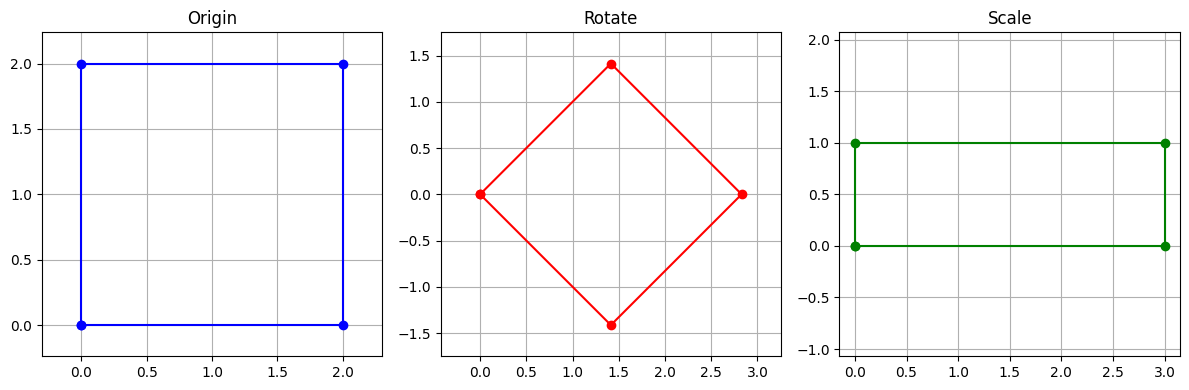

In [23]:
M = np.array([[0, 2, 2, 0, 0],[0, 0, 2, 2, 0]])
R = M.T @ rotation_matrix(45)
S = M.T @ scaling_matrix(1.5,0.5)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
R = R.T
S = S.T
plt.plot(M[0],M[1], 'b-o', label = 'Original')
plt.grid(True); plt.axis('equal'); plt.title('Origin')

plt.subplot(1,3,2)
plt.plot(R[0],R[1], 'r-o', label = 'Rotate')
plt.grid(True); plt.axis('equal'); plt.title('Rotate')

plt.subplot(1,3,3)
plt.plot(S[0],S[1], 'g-o', label = 'Scale')
plt.grid(True); plt.axis('equal'); plt.title('Scale')
plt.tight_layout()
plt.show()


### Nén ảnh bằng SVD. Phân rã M = UΣV ⊤; giữ lại k giá trị kỳ dị lớn nhất (thử k = 5,20,50), tái tạo và hiển thị ảnh để so sánh.

(400, 400)


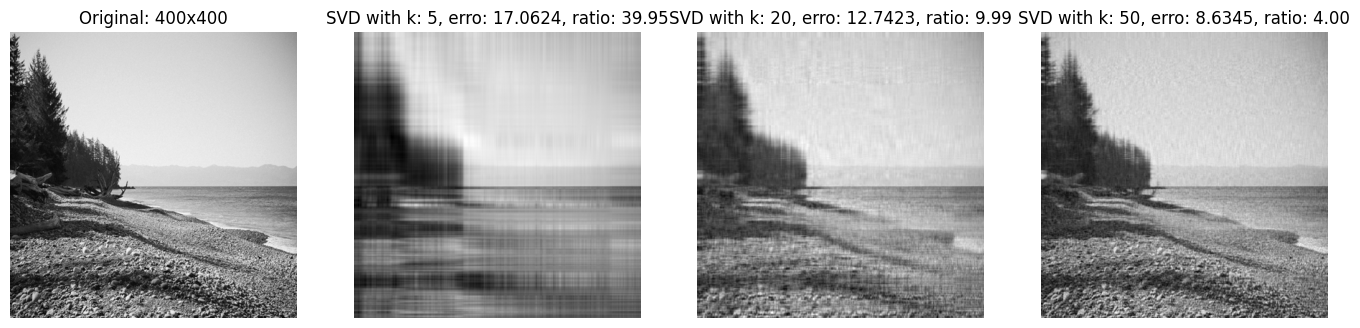

In [24]:
img = Image.open(f'GreyScale/image0.png')
img = img.resize((400,400))
img.save(f'simple_picture.png')

X = np.array(img,dtype=float)
print(X.shape)

U, S, Vt = np.linalg.svd(X, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k_value = [5,20,50]
plt.figure(figsize=(17,5))
plt.subplot(1,4,1)
plt.imshow(X, cmap='gray')
plt.title(f"Original: 400x400")
plt.axis('off')

for i, k in enumerate(k_value, start=2):
    M_ = reconstruct(k)
    original = 400*400
    compress = k*(400 + 400 + 1)
    ratio = original/compress
    error = np.linalg.norm(X - M_, 'fro') / np.linalg.norm(M_, 'fro') * 100
    plt.subplot(1, 4, i)
    plt.imshow(M_, cmap='gray')
    plt.title(f"SVD with k: {k}, erro: {error:.4f}, ratio: {ratio:.2f}")
    plt.axis('off')


### Đánh giá. Tính tỉ lệ nén và sai số tái tạo theo từng k; vẽ đồ thị sai số theo k


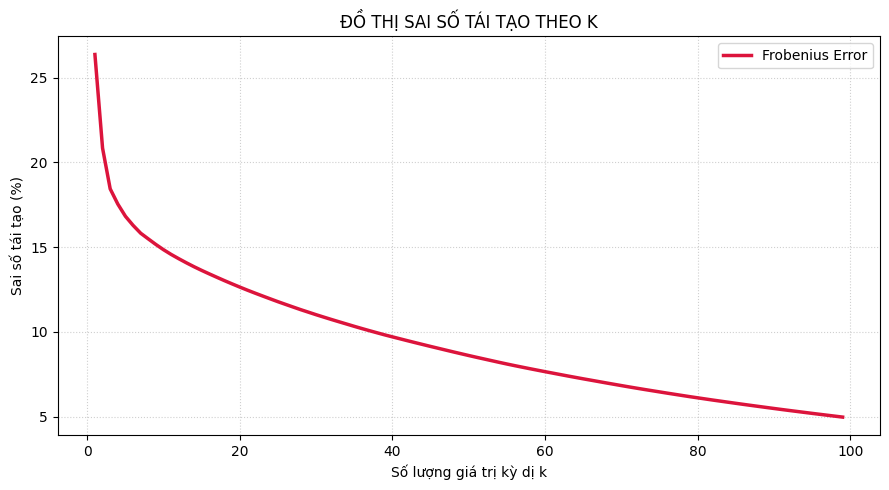

In [25]:
all_k = np.arange(1, 100, 1)
error_list = []
for k in all_k:
    M_ = reconstruct(k)
    error = np.linalg.norm(X - M_, 'fro') / np.linalg.norm(X, 'fro') * 100
    error_list.append(error)

plt.figure(figsize=(9, 5))
plt.plot(all_k, error_list, color='crimson', linestyle='-', linewidth=2.5, label='Frobenius Error')
plt.xlabel('Số lượng giá trị kỳ dị k')
plt.ylabel('Sai số tái tạo (%)')
plt.title('ĐỒ THỊ SAI SỐ TÁI TẠO THEO K')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Voi k = 20 la muc van chap nhan duoc, k = 50 la muc chat luong anh kha tuong dong voi anh goc sai so < 10%. 
Viec giam chieu va nen du lieu trong AI co the tiet kiem tai nguyen tinh toan -> tang toc do, tiet kiem ram
Giam su nhieu gay ra boi cac diem anh khong quan trong -> tang do chinh xac 